<a href="https://colab.research.google.com/github/pras1978/fitness-journey-analyzer/blob/main/notebooks/04_nlp_workout_log_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2 — Import libraries

In [3]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cell 3 — Define paths

In [4]:
BASE_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/data"

nlp_path = os.path.join(BASE_PATH, "nlp", "sentiment140")
print("NLP path exists:", os.path.exists(nlp_path))
print(os.listdir(nlp_path))

NLP path exists: True
['training.csv']


Cell 4 — Load Sentiment140 dataset

In [5]:
nlp_file = os.path.join(nlp_path, os.listdir(nlp_path)[0])
df = pd.read_csv(nlp_file, encoding="latin-1", header=None)
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


Cell 5 — Keep useful columns only

In [6]:
df = df[[0, 5]]
df.columns = ["sentiment", "text"]

df["sentiment"] = df["sentiment"].replace({0: "negative", 4: "positive"})
df.head()

,sentiment,text
0,negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,negative,is upset that he can't update his Facebook by ...
2,negative,@Kenichan I dived many times for the ball. Man...
3,negative,my whole body feels itchy and like its on fire
4,negative,"@nationwideclass no, it's not behaving at all...."


Cell 6 — Check dataset size and balance

In [7]:
print(df.shape)
print(df["sentiment"].value_counts())

(1600000, 2)
sentiment
negative    800000
positive    800000
Name: count, dtype: int64


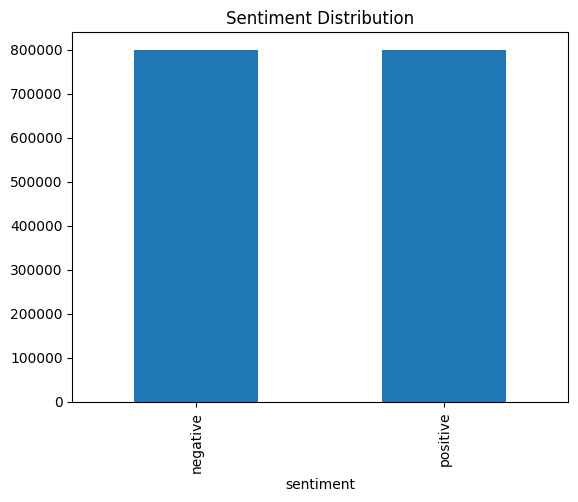

In [8]:
df["sentiment"].value_counts().plot(kind="bar", title="Sentiment Distribution")
plt.show()

Cell 7 — Clean text

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

,sentiment,text,clean_text
0,negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,negative,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,negative,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,negative,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,negative,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


Cell 8 — Create custom workout logs

In [11]:
fitness_logs = [
    "felt strong today lifted 80kg bench press",
    "too tired today skipped workout",
    "great leg day squats felt powerful",
    "low energy workout today",
    "amazing push workout feeling confident",
    "very sore and exhausted after training",
    "light workout but felt good",
    "intense session high effort today"
]

df_custom = pd.DataFrame({"text": fitness_logs})
df_custom["clean_text"] = df_custom["text"].apply(clean_text)
df_custom

,text,clean_text
0,felt strong today lifted 80kg bench press,felt strong today lifted 80kg bench press
1,too tired today skipped workout,too tired today skipped workout
2,great leg day squats felt powerful,great leg day squats felt powerful
3,low energy workout today,low energy workout today
4,amazing push workout feeling confident,amazing push workout feeling confident
5,very sore and exhausted after training,very sore and exhausted after training
6,light workout but felt good,light workout but felt good
7,intense session high effort today,intense session high effort today


Cell 9 — Install transformers

In [13]:
!pip install transformers torch -q

Cell 10 — Load sentiment pipeline

In [14]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Cell 11 — Test sentiment on custom logs

In [15]:
sentiment_results = df_custom["clean_text"].apply(lambda x: sentiment_pipeline(x)[0])
df_custom["sentiment_label"] = sentiment_results.apply(lambda x: x["label"])
df_custom["sentiment_score"] = sentiment_results.apply(lambda x: x["score"])

df_custom

,text,clean_text,sentiment_label,sentiment_score
0,felt strong today lifted 80kg bench press,felt strong today lifted 80kg bench press,POSITIVE,0.999512
1,too tired today skipped workout,too tired today skipped workout,NEGATIVE,0.999053
2,great leg day squats felt powerful,great leg day squats felt powerful,POSITIVE,0.998333
3,low energy workout today,low energy workout today,NEGATIVE,0.998666
4,amazing push workout feeling confident,amazing push workout feeling confident,POSITIVE,0.999825
5,very sore and exhausted after training,very sore and exhausted after training,NEGATIVE,0.999738
6,light workout but felt good,light workout but felt good,POSITIVE,0.999493
7,intense session high effort today,intense session high effort today,POSITIVE,0.999740


Cell 12 — Convert labels to simple format

In [16]:
df_custom["sentiment_label"] = df_custom["sentiment_label"].str.lower()
df_custom

,text,clean_text,sentiment_label,sentiment_score
0,felt strong today lifted 80kg bench press,felt strong today lifted 80kg bench press,positive,0.999512
1,too tired today skipped workout,too tired today skipped workout,negative,0.999053
2,great leg day squats felt powerful,great leg day squats felt powerful,positive,0.998333
3,low energy workout today,low energy workout today,negative,0.998666
4,amazing push workout feeling confident,amazing push workout feeling confident,positive,0.999825
5,very sore and exhausted after training,very sore and exhausted after training,negative,0.999738
6,light workout but felt good,light workout but felt good,positive,0.999493
7,intense session high effort today,intense session high effort today,positive,0.999740


Cell 13 — Add effort and fatigue rules

In [17]:
def detect_effort(text):
    text = text.lower()
    high_words = ["strong", "intense", "powerful", "heavy", "great", "amazing"]
    low_words = ["light", "skipped", "low energy", "tired"]

    if any(word in text for word in high_words):
        return "high"
    elif any(word in text for word in low_words):
        return "low"
    else:
        return "medium"

def detect_fatigue(text):
    text = text.lower()
    high_words = ["tired", "exhausted", "sore", "skipped"]
    low_words = ["strong", "good", "confident", "powerful"]

    if any(word in text for word in high_words):
        return "high"
    elif any(word in text for word in low_words):
        return "low"
    else:
        return "medium"

df_custom["effort_label"] = df_custom["clean_text"].apply(detect_effort)
df_custom["fatigue_label"] = df_custom["clean_text"].apply(detect_fatigue)

df_custom

,text,clean_text,sentiment_label,sentiment_score,effort_label,fatigue_label
0,felt strong today lifted 80kg bench press,felt strong today lifted 80kg bench press,positive,0.999512,high,low
1,too tired today skipped workout,too tired today skipped workout,negative,0.999053,low,high
2,great leg day squats felt powerful,great leg day squats felt powerful,positive,0.998333,high,low
3,low energy workout today,low energy workout today,negative,0.998666,low,medium
4,amazing push workout feeling confident,amazing push workout feeling confident,positive,0.999825,high,low
5,very sore and exhausted after training,very sore and exhausted after training,negative,0.999738,medium,high
6,light workout but felt good,light workout but felt good,positive,0.999493,low,low
7,intense session high effort today,intense session high effort today,positive,0.999740,high,medium


Cell 14 — Visualize results

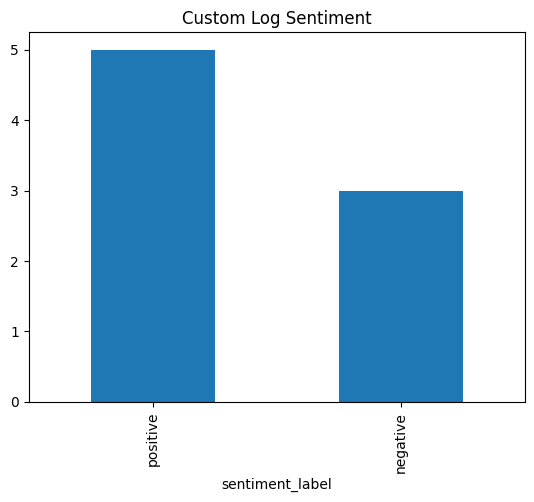

In [18]:
df_custom["sentiment_label"].value_counts().plot(kind="bar", title="Custom Log Sentiment")
plt.show()

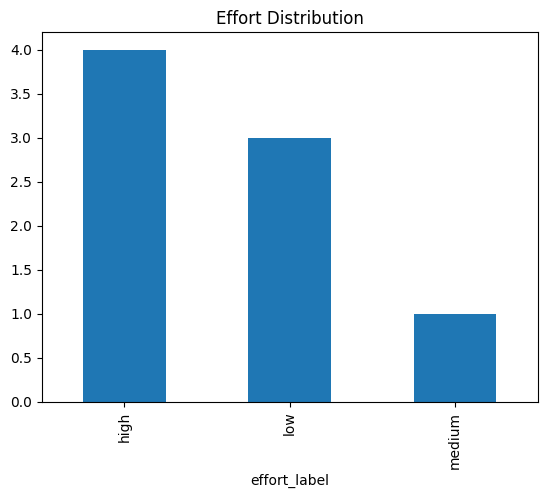

In [19]:
df_custom["effort_label"].value_counts().plot(kind="bar", title="Effort Distribution")
plt.show()

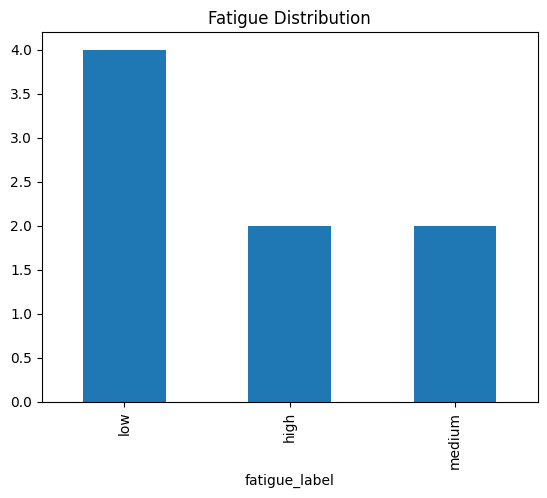

In [20]:
df_custom["fatigue_label"].value_counts().plot(kind="bar", title="Fatigue Distribution")
plt.show()

Cell 15 — Save results

In [21]:
output_dir = "/content/drive/MyDrive/fitness-journey-analyzer/data/processed"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "nlp_workout_log_results.csv")
df_custom.to_csv(output_file, index=False)

print("Saved to:", output_file)

Saved to: /content/drive/MyDrive/fitness-journey-analyzer/data/processed/nlp_workout_log_results.csv
